In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

In [25]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate



In [26]:
llm = ChatOpenAI(
    model="gpt-3.5-turbo-0613"
)    

print("LLM initialized with model:", llm.model_name)

LLM initialized with model: gpt-3.5-turbo-0613


In [3]:
from langchain_groq import ChatGroq
from langchain.tools import tool
llm = ChatGroq(
    model_name="deepseek-r1-distill-llama-70b",
    temperature=0
)
response=llm.invoke("what is length of wall of china?")

In [4]:
response_text = response.content
print("Response from Groq LLM:", response_text)

Response from Groq LLM: <think>
Okay, so I need to figure out the length of the Great Wall of China. I remember hearing that it's really long, but I'm not exactly sure how long. I think it's somewhere in the thousands of miles, but I'm not certain. Let me try to break this down.

First, I know the Great Wall is a series of fortifications built across several Chinese dynasties. It wasn't built all at once, so maybe that's why the length can vary. I've heard different numbers before, like 13,000 miles or 21,000 kilometers. But I'm not sure which one is accurate.

I should consider the sources of this information. Maybe some people measure it differently. For example, if you include all the branches and sections, it might add up to a longer distance. But if you just take the main wall, it might be shorter. I think the Chinese government did a survey a while back, so that might be a reliable source.

Wait, I think they used advanced technology like GPS and satellites to measure it more acc

In [ ]:
llm.invoke("What is Agentic AI?").content


In [ ]:


from langchain.chat_models import ChatOpenAI
llm = ChatOpenAI(model="o1-mini", temperature=0)

C:\Users\veena\AppData\Local\Temp\ipykernel_15536\1904494471.py:2: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model="o1-mini", temperature=0)


In [ ]:
print("LLM initialized with model:", llm)

LLM initialized with model: client=<openai.resources.chat.completions.completions.Completions object at 0x00000229C78034D0> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000229C7803ED0> model_name='o1-mini' temperature=0.0 model_kwargs={} openai_api_key='sk--utybcmFCh13Axadbo5tHKCjb7NzXzZv-zDoTorCJVT3BlbkFJ_P_m4Oj4yw0Gujyfhs7acAdmQUQ4KPNa0sOstliQEA' openai_proxy=''


In [ ]:
llm.invoke("What is Agentic AI?").content

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [6]:
search.invoke("what is the latest update on iphone17 release?")

"Forbes iOS 26 Release Date: Exactly When The New iPhone Software Will Launch By David Phelan. This gives us three possible pairs of dates: Tuesday, Sept. 2 or Wednesday, Sept. 3, Tuesday, Sept. 9 ... CUPERTINO, CALIFORNIA Apple today previewed iOS 26, a major update that brings a beautiful new design, intelligent experiences, and improvements to the apps users rely on every day. The new design provides a more expressive and delightful experience across the system while maintaining the instant familiarity of iOS. Planned for September 2025, the iPhone 17 models could feature larger display sizes, ProMotion across the lineup, Wi-Fi 7, and more. We're still in the middle of the iPhone 16 release cycle, but ... Apple's upcoming iOS 26 update brings a new look and lots of useful features to make your iPhone smarter and easier to use. The design is getting a refresh. The lock screen clock now stretches across the full screen, Safari has a cleaner look with edge-to-edge browsing and a floati

In [7]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain.tools import tool
import random

In [8]:
@tool
def get_weather(city: str) -> str:
    """
    Returns a simulated current weather update for a given city.

    Args:
        city (str): The name of the city.

    Returns:
        str: A random temperature with weather condition.
    """
    return f"Current weather in {city} is {random.randint(22, 35)}°C with light breeze."

In [9]:
@tool
def get_attractions(city: str) -> str:
    """
    Lists top tourist attractions in a given city.

    Args:
        city (str): The name of the city.

    Returns:
        str: A sample list of attractions.
    """
    return f"Top attractions in {city} include The Grand Museum, Central Park, and Historic Downtown."

In [10]:
@tool
def get_hotels(city: str, days: int, budget: int) -> str:
    """
    Estimates hotel costs based on the city, duration, and daily budget.

    Args:
        city (str): The destination city.
        days (int): Number of days for the stay.
        budget (int): Daily hotel budget in local currency.

    Returns:
        str: Estimated total hotel cost.
    """
    cost = days * budget
    return f"Estimated hotel cost in {city} for {days} days within your budget is ₹{cost}."

In [11]:
@tool
def currency_convert(amount: float, to_currency: str) -> str:
    """
    Converts an amount from USD to the specified currency.

    Args:
        amount (float): The amount in USD.
        to_currency (str): Target currency (e.g., INR).

    Returns:
        str: Converted currency string.
    """
    rate = 83.2 if to_currency == "INR" else 1.0
    return f"{amount} USD is approximately ₹{amount * rate:.2f} {to_currency}."

In [12]:
@tool
def calculate_total_cost(hotel: int, food: int, travel: int) -> str:
    """
    Calculates total trip cost by summing hotel, food, and travel costs.

    Args:
        hotel (int): Hotel cost.
        food (int): Food cost.
        travel (int): Transportation cost.

    Returns:
        str: Total cost as a formatted string.
    """
    return f"Total trip cost estimate: ₹{hotel + food + travel}"

In [13]:
@tool
def get_itinerary(city: str, days: int) -> str:
    """
    Generates a simple day-wise itinerary for a given city.

    Args:
        city (str): Destination city.
        days (int): Number of days for the trip.

    Returns:
        str: Sample itinerary string.
    """
    return f"Day-wise itinerary in {city}:"  
               

In [ ]:
@tool
def search_activitiesfunc(city: str) -> str:
    """
    Suggests fun and popular activities in a specific city for tourists.

    Args:
        city (str): The name of the city.

    Returns:
        str: A sample list of recommended activities.
    """
    return f"Popular activities in {city} include food tours, river cruises, biking around the old town, and attending local cultural events."



In [14]:
from langchain.chat_models import ChatOpenAI
from langchain.agents import initialize_agent, AgentType

In [15]:
### ---------------------- TOOL LIST ---------------------- ###
tools = [get_weather, get_attractions, get_hotels, currency_convert,
         calculate_total_cost, get_itinerary, search]

In [ ]:
##bind tools to the LLM
from langchain.agents import initialize_agent
llm_with_tools = initialize_agent(
    tools=tools,
    llm=llm,
    agent=AgentType.OPENAI_FUNCTIONS,
    verbose=True
)

C:\Users\veena\AppData\Local\Temp\ipykernel_15536\798971587.py:3: LangChainDeprecationWarning: LangChain agents will continue to be supported, but it is recommended for new use cases to be built with LangGraph. LangGraph offers a more flexible and full-featured framework for building agents, including support for tool-calling, persistence of state, and human-in-the-loop workflows. For details, refer to the `LangGraph documentation <https://langchain-ai.github.io/langgraph/>`_ as well as guides for `Migrating from AgentExecutor <https://python.langchain.com/docs/how_to/migrate_agent/>`_ and LangGraph's `Pre-built ReAct agent <https://langchain-ai.github.io/langgraph/how-tos/create-react-agent/>`_.
  llm_with_tools = initialize_agent(


In [16]:
llm_with_tools = llm.bind_tools(tools)


In [17]:
response = llm_with_tools.invoke("hi")
response.content


"Hello! How can I assist you with your travel plans today? Whether you need to check the weather, find attractions, book hotels, or create an itinerary, I'm here to help!"

In [18]:
response.tool_calls

[]

In [19]:
response=llm_with_tools.invoke("what is weather in delhi?")

In [20]:
response.content

''

In [21]:
response.tool_calls

[{'name': 'get_weather',
  'args': {'city': 'Delhi'},
  'id': 'kxttweenm',
  'type': 'tool_call'}]

In [22]:
response=llm_with_tools.invoke("Plan me iternary for 3 days in delhi")
response.content

''

In [23]:
response.tool_calls

[{'name': 'get_itinerary',
  'args': {'city': 'Delhi', 'days': 3},
  'id': 'h99rb8ae4',
  'type': 'tool_call'}]

In [24]:
response=llm_with_tools.invoke("what are the top attractions in delhi?")
response.content

''

In [25]:
response.tool_calls

[{'name': 'get_attractions',
  'args': {'city': 'Delhi'},
  'id': 'yyvsz4x7x',
  'type': 'tool_call'}]

In [26]:
response=llm_with_tools.invoke("What will be the total cost of trip for 3 days in delhi with hotel budget of 2000 per day, food budget of 1000 per day and travel budget of 500 per day?")
response.content

''

In [27]:
response.tool_calls

[{'name': 'calculate_total_cost',
  'args': {'food': 1000, 'hotel': 2000, 'travel': 500},
  'id': 'xf9tcqd3v',
  'type': 'tool_call'}]

In [30]:
response=llm_with_tools.invoke("Convert 100 USD to INR")
response.content

''

In [31]:
response.tool_calls

[{'name': 'currency_convert',
  'args': {'amount': 100, 'to_currency': 'INR'},
  'id': 'a9d9v2gmx',
  'type': 'tool_call'}]

In [32]:
response=llm_with_tools.invoke("Estimate hotel cost in delhi for 3 days with budget of 2000 per day")
response.content

''

In [33]:
response.tool_calls

[{'name': 'get_hotels',
  'args': {'budget': 2000, 'city': 'Delhi', 'days': 3},
  'id': '5cvc7ak4r',
  'type': 'tool_call'}]

In [34]:
response=llm_with_tools.invoke("Prime minister of china?")
response

AIMessage(content='', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 696, 'total_tokens': 724, 'completion_time': 0.101818182, 'prompt_time': 0.044717024, 'queue_time': 0.058313699000000004, 'total_time': 0.146535206}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--07c1265d-1240-4efc-a4f0-123eaf6f94c2-0', usage_metadata={'input_tokens': 696, 'output_tokens': 28, 'total_tokens': 724})

In [35]:
response.tool_calls

[]

In [36]:
SYSTEM_PROMPT = SystemMessage(
    content="You are a helpful travel assistant. Use tools to find weather, activities, hotel costs, convert currency, calculate budget, and generate itinerary. You can also search . If you don't know the answer, say 'I don't know'."
)

In [37]:
user_query=["tell me what is weather in delhi?",
            "what are the top attractions in delhi?",]

In [38]:
[SYSTEM_PROMPT]+user_query

[SystemMessage(content="You are a helpful travel assistant. Use tools to find weather, activities, hotel costs, convert currency, calculate budget, and generate itinerary. You can also search . If you don't know the answer, say 'I don't know'.", additional_kwargs={}, response_metadata={}),
 'tell me what is weather in delhi?',
 'what are the top attractions in delhi?']

In [39]:
def planner_function(state: MessagesState):
    user_input = state["messages"]
    input_question = [SYSTEM_PROMPT] + user_input
    response = llm_with_tools.invoke(input_question)
    return {"messages": [response]}

In [40]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START

In [41]:
builder=StateGraph(MessagesState)

In [42]:
builder.add_node("llm_decision_step",planner_function)

In [43]:
tools

[StructuredTool(name='get_weather', description='Returns a simulated current weather update for a given city.\n\nArgs:\n    city (str): The name of the city.\n\nReturns:\n    str: A random temperature with weather condition.', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x000002E062B6C7C0>),
 StructuredTool(name='get_attractions', description='Lists top tourist attractions in a given city.\n\nArgs:\n    city (str): The name of the city.\n\nReturns:\n    str: A sample list of attractions.', args_schema=<class 'langchain_core.utils.pydantic.get_attractions'>, func=<function get_attractions at 0x000002E05F050FE0>),
 StructuredTool(name='get_hotels', description='Estimates hotel costs based on the city, duration, and daily budget.\n\nArgs:\n    city (str): The destination city.\n    days (int): Number of days for the stay.\n    budget (int): Daily hotel budget in local currency.\n\nReturns:\n    str: Estimated total hotel cost.', args_sche

In [44]:
from langgraph.prebuilt import ToolNode
builder.add_node("tools",ToolNode(tools))

In [45]:
builder.add_edge(START,"llm_decision_step")

In [46]:
from langgraph.prebuilt import tools_condition
builder.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)

In [47]:
builder.add_edge("tools","llm_decision_step")

In [48]:
react_graph=builder.compile()

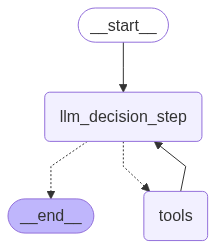

In [49]:
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [50]:
message=[HumanMessage(content="Prepare me an iternary for 3 days in delhi")]

In [54]:
response=react_graph.invoke({"messages":message})

In [55]:
response["messages"][-1].content

"Here’s a suggested 3-day itinerary for Delhi:\n\n---\n\n### **Day 1: Historical Delhi**\n- **Morning:**  \n  - Visit the **Red Fort** (Lal Qila), a UNESCO World Heritage Site.  \n  - Explore the **Jama Masjid**, one of India's largest mosques.  \n- **Lunch:** Enjoy street food at **Chandni Chowk** or **Paranthe Wali Gali**.  \n- **Afternoon:**  \n  - Head to the **Qutub Minar**, another UNESCO World Heritage Site.  \n  - Visit the **India Gate** and take a stroll around the **Rajpath**.  \n- **Evening:**  \n  - Relax at **Lodi Gardens** or **Connaught Place**.  \n  - Dinner at **Karim’s** for authentic Mughlai cuisine.  \n\n---\n\n### **Day 2: Cultural & Spiritual Delhi**\n- **Morning:**  \n  - Visit the **Lotus Temple** (Bahá'í Temple).  \n  - Explore the **Akshardham Temple** for its stunning architecture.  \n- **Lunch:** Dine at **Hauz Khas Village** or **Punjabi By Nature**.  \n- **Afternoon:**  \n  - Visit the **National Museum** to learn about India's history.  \n  - Explore the

In [56]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Prepare me an iternary for 3 days in delhi
================================== Ai Message ==================================
Tool Calls:
  get_itinerary (hec489j0b)
 Call ID: hec489j0b
  Args:
    city: Delhi
    days: 3
================================= Tool Message =================================
Name: get_itinerary

Day-wise itinerary in Delhi:
================================== Ai Message ==================================

Here’s a suggested 3-day itinerary for Delhi:

---

### **Day 1: Historical Delhi**
- **Morning:**  
  - Visit the **Red Fort** (Lal Qila), a UNESCO World Heritage Site.  
  - Explore the **Jama Masjid**, one of India's largest mosques.  
- **Lunch:** Enjoy street food at **Chandni Chowk** or **Paranthe Wali Gali**.  
- **Afternoon:**  
  - Head to the **Qutub Minar**, another UNESCO World Heritage Site.  
  - Visit the **India Gate** and take a stroll around the **Rajpath**.  
- 

In [57]:
message=[HumanMessage(content="Search attraction in delhi")]

In [59]:
response=react_graph.invoke({"messages":message})

In [60]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Search attraction in delhi
================================== Ai Message ==================================
Tool Calls:
  get_attractions (c6e2wgdfb)
 Call ID: c6e2wgdfb
  Args:
    city: Delhi
================================= Tool Message =================================
Name: get_attractions

Top attractions in Delhi include The Grand Museum, Central Park, and Historic Downtown.
================================== Ai Message ==================================

Top attractions in Delhi include The Grand Museum, Central Park, and Historic Downtown.


In [65]:
message=[HumanMessage(content="what is historic downtown in delhi?")]

In [66]:
react_graph.invoke({"messages":message})

{'messages': [HumanMessage(content='what is historic downtown in delhi?', additional_kwargs={}, response_metadata={}, id='c01749f1-1e15-4d2a-af21-043d2f768b8b'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'whgn3ce9m', 'function': {'arguments': '{"query":"historic downtown in Delhi"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 293, 'prompt_tokens': 746, 'total_tokens': 1039, 'completion_time': 1.205009685, 'prompt_time': 0.055422988, 'queue_time': 0.056491743000000004, 'total_time': 1.260432673}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--bcf60780-df4f-4c6d-b2eb-e5dd4f4c9d63-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'historic downtown in Delhi'}, 'id': 'whgn3ce9m', 'type': 'tool_call'}], usage_metadata={'input_tokens': 746, 'output_tokens': 293, 'total_tokens': 1039}),
  ToolMe

In [68]:
for m in react_graph.invoke({"messages":message})["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is historic downtown in delhi?
================================== Ai Message ==================================

Historic downtown in Delhi typically refers to Old Delhi, which is one of the oldest parts of the city. It is known for its rich history, cultural landmarks, and vibrant markets. Some of the key attractions in Old Delhi include:

1. **Red Fort (Lal Qila)**: A UNESCO World Heritage Site and a symbol of India's Mughal history.
2. **Jama Masjid**: One of the largest mosques in India, built by Shah Jahan.
3. **Chandni Chowk**: A bustling marketplace that has been in operation since the 17th century.
4. **Spice Market (Khari Baoli)**: Asia's largest spice market, offering a variety of spices and herbs.

Old Delhi is a must-visit for anyone interested in history, architecture, and experiencing the vibrant culture of Delhi.


In [69]:
message=[HumanMessage(content="search a good restaurant in delhi ")]

In [70]:
for m in react_graph.invoke({"messages":message})["messages"]:
    m.pretty_print()

================================ Human Message =================================

search a good restaurant in delhi 
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (zvwx3gbjc)
 Call ID: zvwx3gbjc
  Args:
    query: best restaurants in Delhi
================================= Tool Message =================================
Name: duckduckgo_search

From the right vendors for perfect street food in the old city to the fine dining spots to reserve ahead, here are a local food editor's top picks for dining in New Delhi. Delhi local Raghav Modi has a thing about food. Here, he shares his picks for the best restaurants in Delhi, India for every budget. New Delhi is home to distinctive eateries that serve great delicacies made using fresh local ingredients. These dining spots are pushing boundaries, and leading the way with their innovative ... Discover the top 10 must-visit restaurants in Delhi for 2025—from iconic fine dining to